In [2]:
import csv
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from math import log, sqrt

from ipykernel.eventloops import loop_wx_exit

In [19]:
# load all the data from a csv file
def loadDataMoreInputs(fileName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    return dataNames, data


In [36]:
# extract a particular feature (column)
def extractFeature(allData, names, featureName):
    pos = names.index(featureName)
    return [float(data[pos]) for data in allData]

In [ ]:
# plot a histogram for some data x
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 20)
    plt.title('Histogram of ' + variableName)
    plt.show()

In [5]:
def loadData(fileName):
    df = pd.read_csv(fileName, skiprows=1,low_memory=False)
    print(df.head())
    
loadData('data/surveyDataSience.csv')

   Duration (in seconds) What is your age (# years)?  \
0                    910                       50-54   
1                    784                       50-54   
2                    924                       22-24   
3                    575                       45-49   
4                    781                       45-49   

  What is your gender? - Selected Choice  \
0                                    Man   
1                                    Man   
2                                    Man   
3                                    Man   
4                                    Man   

  In which country do you currently reside?  \
0                                     India   
1                                 Indonesia   
2                                  Pakistan   
3                                    Mexico   
4                                     India   

  What is the highest level of formal education that you have attained or plan to attain within the next 2 years?  

In [10]:
#numarul de respondenti (de la care s-au colectate informatiile)
def nrResp(fileName):
    df = pd.read_csv(fileName, low_memory=False, skiprows=1)
    return df.shape[0]

print(nrResp('data/surveyDataSience.csv'))

25973


In [7]:
#numar si tipul informatiilor (atributelor, proprietatilor) detinute pentru un respondent
def extract_resp_data(fileName, resp_index=1, resp_id=None):
    df = pd.read_csv(fileName, low_memory=False)
    if resp_id is not None:
        # Căutare după ID (prima coloană)
        respondent = df[df.iloc[:, 0] == resp_id]
        if len(respondent) == 0:
            print(f"Nu s-a găsit respondentul cu ID-ul: {resp_id}")
            return None
        respondent_data = respondent.iloc[0]
    else:
        # Extragere după index
        if resp_index >= len(df):
            print(f"Indexul {resp_index} depășește numărul de respondenți ({len(df)})")
            return None
        respondent_data = df.iloc[resp_index]
    
    return respondent_data

print(extract_resp_data('data/surveyDataSience.csv').dropna())

Time from Start to Finish (seconds)                                                  910
Q1                                                                                 50-54
Q2                                                                                   Man
Q3                                                                                 India
Q4                                                                     Bachelor’s degree
                                                             ...                        
Q42_Part_4                                               Kaggle (notebooks, forums, etc)
Q42_Part_6                             YouTube (Kaggle YouTube, Cloud AI Adventures, ...
Q42_Part_7                             Podcasts (Chai Time Data Science, O’Reilly Dat...
Q42_Part_8                             Blogs (Towards Data Science, Analytics Vidhya,...
Q42_Part_9                             Journal Publications (peer-reviewed journals, ...
Name: 1, Length: 62, 

In [27]:
#numar si tipul informatiilor (atributelor, proprietatilor) detinute pentru un respondent
def nr_tip(x):
    df = pd.read_csv('data/surveyDataSience.csv', skiprows=1,  low_memory=False)
    tipuri= df.dtypes.value_counts()
    resp=df.iloc[x]
    
    return {
        'respondent_index': x,
        'number_of_attributes': len(resp),
        'attribute_types': tipuri,
    }
    
print(nr_tip(1))

{'respondent_index': 1, 'number_of_attributes': 369, 'attribute_types': str        338
float64     30
int64        1
Name: count, dtype: int64}


In [84]:
def respondenti_date_complete(fileName):
    df = pd.read_csv(fileName, low_memory=False)
    
    intrebari = set()
    for col in df.columns:
        # "Q1" din "Q1_Part1" sau "Q1" 
        if '_' in col:
            prefix = col.split('_')[0]  # Q1_Part1 -> Q1
        else:
            prefix = col
        intrebari.add(prefix)
    
    coloane_pe_intrebare = {intrebare: [] for intrebare in intrebari}
    
    for intrebare in intrebari:
        for col in df.columns:
            if col == intrebare:
                coloane_pe_intrebare[intrebare].append(col)
            elif col.startswith(intrebare + '_'):
                coloane_pe_intrebare[intrebare].append(col)
    
    
    respondenti_completi = 0
    indecsi_completi = []
    
    for idx, respondent in df.iterrows():
        complet = True
        
        for intrebare in intrebari:
            coloane_intrebare = coloane_pe_intrebare[intrebare]
            
            are_raspuns = False
            for col in coloane_intrebare:
                if pd.notna(respondent[col]):
                    are_raspuns = True
                    break
            
            if not are_raspuns:
                complet = False
                break
        
        if complet:
            respondenti_completi += 1
            indecsi_completi.append(idx)
    
    return respondenti_completi

rezultat = respondenti_date_complete('data/surveyDataSience.csv')
print(f"\ndate complete: {rezultat}")



date complete: 202


In [49]:
def media_studii_c5(filepath):
    df = pd.read_csv(filepath, low_memory=False)

    #valori text -> ani de studiu
    mapare_ani = {
        # Bachelor's degree - 3 ani
        'Bachelor’s degree': 3,
        "Bachelor's degree": 3,
        

        # Master's degree - 5 ani (3+2)
        'Master’s degree': 5,
        "Master's degree": 5,

        # Doctoral degree / PhD - 8 ani (3+2+3)
        'Doctoral degree': 8,
        'Doctorate': 8,

        # Some college / studii universitare incomplete
        'Some college/university study without earning a bachelor’s degree': 1,
        'Some college/university study': 1,
        'Some college': 1,
        'University study': 1,

        # No formal education past high school
        'No formal education past high school': 0,
        'No formal education': 0,
        'High school only': 0,

        # I prefer not to answer
        'I prefer not to answer': np.nan,
        'Prefer not to answer': np.nan,
        'Prefer not to say': np.nan,
    }


    media_globala = df['Q4'].dropna().map(mapare_ani).mean()


    print(f"\n🎓 MEDIA GLOBALĂ: {media_globala:.2f} ani")


    return media_globala

media = media_studii_c5('data/surveyDataSience.csv')


🎓 MEDIA GLOBALĂ: 4.18 ani


In [56]:
def media_studii_ro(filepath):
    df = pd.read_csv(filepath, low_memory=False)

    #valori text -> ani de studiu
    mapare_ani = {
        # Bachelor's degree - 3 ani
        'Bachelor’s degree': 3,
        "Bachelor's degree": 3,
        

        # Master's degree - 5 ani (3+2)
        'Master’s degree': 5,
        "Master's degree": 5,

        # Doctoral degree / PhD - 8 ani (3+2+3)
        'Doctoral degree': 8,
        'Doctorate': 8,

        # Some college / studii universitare incomplete
        'Some college/university study without earning a bachelor’s degree': 1,
        'Some college/university study': 1,
        'Some college': 1,
        'University study': 1,

        # No formal education past high school
        'No formal education past high school': 0,
        'No formal education': 0,
        'High school only': 0,

        # I prefer not to answer
        'I prefer not to answer': np.nan,
        'Prefer not to answer': np.nan,
        'Prefer not to say': np.nan,
    }

    coloana_tara = 'Q3' 
    coloana_educatie = 'Q4'  
    coloana_gen = 'Q2'
    
    # 🔴 CORECT: Filtrează pentru România MAI ÎNTÂI
    masca_romania = df[coloana_tara].astype(str).str.contains('Romania', case=False, na=False)
    df_romania = df[masca_romania]
    
    #femei romania
    masca_femei = df_romania[coloana_gen].astype(str).str.contains('Woman', case=False, na=False)
    df_femei = df_romania[masca_femei]
    
    ani_studii_romania = df_romania[coloana_educatie].map(mapare_ani)
    media_romania = ani_studii_romania.mean()
    
    ani_studii_femei = df_femei[coloana_educatie].map(mapare_ani)
    media_femei = ani_studii_femei.mean()

    print(f"\n🎓 MEDIA RO: {media_romania:.2f} ani")
    print(f"\n🎓 MEDIA RO FEMEI: {media_femei:.2f} ani")
    
    return media_romania, media_femei

mediaro, mediaro_ladies = media_studii_ro('data/surveyDataSience.csv')


🎓 MEDIA RO: 4.54 ani

🎓 MEDIA RO FEMEI: 5.13 ani


In [62]:
def media_studii_ro(filepath):
    df = pd.read_csv(filepath, low_memory=False, skiprows=1)

    mapare_ani = {
        # Bachelor's degree - 3 ani
        'Bachelor’s degree': 3,
        "Bachelor's degree": 3,


        # Master's degree - 5 ani (3+2)
        'Master’s degree': 5,
        "Master's degree": 5,

        # Doctoral degree / PhD - 8 ani (3+2+3)
        'Doctoral degree': 8,
        'Doctorate': 8,

        # Some college / studii universitare incomplete
        'Some college/university study without earning a bachelor’s degree': 1,
        'Some college/university study': 1,
        'Some college': 1,
        'University study': 1,

        # No formal education past high school
        'No formal education past high school': 0,
        'No formal education': 0,
        'High school only': 0,

        # I prefer not to answer
        'I prefer not to answer': np.nan,
        'Prefer not to answer': np.nan,
        'Prefer not to say': np.nan,
    }

    # Correct column indices: 2=gender, 3=country, 4=education
    df_subset = df.iloc[:, [2, 3, 4]]
    df_subset.columns = ["gender", "country", "education"]

    df_filtered = df_subset[
        (df_subset["country"] == "Romania") &
        (df_subset["gender"] == "Woman")
    ]
    df_filtered1 = df_subset[
        (df_subset["country"] == "Romania")
    ]


    print(f"Rows matched (Romania + Woman): {len(df_filtered)}")

    medie = df_filtered["education"].map(mapare_ani).mean()
    medie_tot=df_filtered1["education"].map(mapare_ani).mean()
    print(f"Media ani: {medie_tot:.2f} ani")
    print(f"Media anilor de studii (Romania, Woman): {medie:.2f}")
    return medie

media_studii_ro("data/surveyDataSience.csv")

Rows matched (Romania + Woman): 16
Media ani: 4.54 ani
Media anilor de studii (Romania, Woman): 5.13


np.float64(5.133333333333334)

In [87]:
#femei date complete
def respondenti_date_complete_romania_femei(fileName):
    df = pd.read_csv(fileName, low_memory=False)
    
    coloana_tara = 'Q3' 
    coloana_educatie = 'Q4'  
    coloana_gen = 'Q2'
    
    masca_romania = df[coloana_tara].astype(str).str.contains('Romania|România', case=False, na=False)
    masca_femei = df[coloana_gen].astype(str).str.contains('Woman|Female|F|Femeie', case=False, na=False)
    
    df_filtrat = df[masca_romania & masca_femei].copy()
    
    print(f"\nTotal femei din România în survey: {len(df_filtrat)}")
    
    if len(df_filtrat) == 0:
        print("Nu s-au găsit femei din România!")
        return 0
    
    
    intrebari = set()
    for col in df_filtrat.columns:
        if '_' in col:
            prefix = col.split('_')[0]
        else:
            prefix = col
        
        if prefix not in [coloana_tara, coloana_gen]:
            intrebari.add(prefix)
    
    print(f"Întrebări de verificat: {len(intrebari)}")
    

    coloane_pe_intrebare = {intrebare: [] for intrebare in intrebari}
    
    for intrebare in intrebari:
        for col in df_filtrat.columns:
            if col == intrebare or col.startswith(intrebare + '_'):
                coloane_pe_intrebare[intrebare].append(col)
    
    respondenti_completi = 0
    indecsi_completi = []
    
    for idx, respondent in df_filtrat.iterrows():
        complet = True
        
        for intrebare in intrebari:
            coloane_intrebare = coloane_pe_intrebare[intrebare]
            
            are_raspuns = False
            for col in coloane_intrebare:
                if pd.notna(respondent[col]):
                    are_raspuns = True
                    break
            
            if not are_raspuns:
                complet = False
                break
        
        if complet:
            respondenti_completi += 1
            indecsi_completi.append(idx)
            
    return respondenti_completi

rezultat = respondenti_date_complete_romania_femei('data/surveyDataSience.csv')
print(f"\ndate complete (femei Romania): {rezultat}")


Total femei din România în survey: 16
Întrebări de verificat: 41

date complete (femei Romania): 0


In [98]:
def analiza_femei_romania_limbaje(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    
    coloana_tara = 'Q3'
    coloana_gen = 'Q2'
    coloana_varsta = 'Q1'
    coloana_limbaj_py = 'Q7_Part_1'
    coloana_limbaj_cpp = 'Q7_Part_5'
    
 
    masca_romania = df[coloana_tara].astype(str).str.contains('Romania', case=False, na=False)
    masca_femei = df[coloana_gen].astype(str).str.contains('Woman', case=False, na=False)
    
    df_romania_femei = df[masca_romania & masca_femei]
    
    
    df_python = df_romania_femei[df_romania_femei[coloana_limbaj_py] == 'Python']
    nr_femei_python = len(df_python)
    
    df_cpp = df_romania_femei[df_romania_femei[coloana_limbaj_cpp] == 'C++']
    nr_femei_cpp = len(df_cpp)
    
    interval_python = df_python[coloana_varsta].mode()[0] if nr_femei_python > 0 else "N/A"
    interval_cpp = df_cpp[coloana_varsta].mode()[0] if nr_femei_cpp > 0 else "N/A"
    
    
    print(f"PYTHON:")
    print(f"   • Număr femei: {nr_femei_python}")
    print(f"   • Interval vârstă (cel mai frecvent): {interval_python}")
    print()
    print(f"C++:")
    print(f"   • Număr femei: {nr_femei_cpp}")
    print(f"   • Interval vârstă (cel mai frecvent): {interval_cpp}")
    
   
    if nr_femei_python > nr_femei_cpp:
        print(f"\nPython este mai popular cu {nr_femei_python - nr_femei_cpp}")
    elif nr_femei_cpp > nr_femei_python:
        print(f"\nC++ este mai popular cu {nr_femei_cpp - nr_femei_python}")
    else:
        print("\nPython și C++ au aceeași popularitate")
    
    return {
        'python': {'numar': nr_femei_python, 'interval_varsta': interval_python},
        'cpp': {'numar': nr_femei_cpp, 'interval_varsta': interval_cpp}
    }

rezultate = analiza_femei_romania_limbaje('data/surveyDataSience.csv')

PYTHON:
   • Număr femei: 12
   • Interval vârstă (cel mai frecvent): 35-39

C++:
   • Număr femei: 4
   • Interval vârstă (cel mai frecvent): 18-21

Python este mai popular cu 8


In [94]:
def femei_cod_python(filepath):
    coloana_tara = 'Q3'
    coloana_gen = 'Q2'
    coloana_varsta = 'Q1'
    coloana_limbaj_python = 'Q7_Part_1'

    df = pd.read_csv(filepath, low_memory=False, header=0, skiprows=[1])

    df_subset = df[[coloana_tara, coloana_gen, coloana_varsta, coloana_limbaj_python]]
    df_filtered = df_subset[
        (df_subset[coloana_tara] == "Romania") &
        (df_subset[coloana_gen] == "Woman") &
        (df_subset[coloana_limbaj_python] == "Python")
    ]

    age_counts = df_filtered[coloana_varsta].value_counts()
    max_count = age_counts.max()
    max_age_group = age_counts[age_counts == max_count].index[0]

    print(f"Most common age group : {max_age_group}")
    print(f"Number of people      : {max_count}")

    print(df_filtered[df_filtered[coloana_varsta] == max_age_group])

femei_cod_python("data/surveyDataSience.csv")

Most common age group : 35-39
Number of people      : 5
            Q3     Q2     Q1 Q7_Part_1
9509   Romania  Woman  35-39    Python
12820  Romania  Woman  35-39    Python
14422  Romania  Woman  35-39    Python
15905  Romania  Woman  35-39    Python
23256  Romania  Woman  35-39    Python


In [95]:
def femei_cod_cpp(filepath):
    coloana_tara = 'Q3'
    coloana_gen = 'Q2'
    coloana_varsta = 'Q1'
    coloana_limbaj_cpp = 'Q7_Part_5'

    df = pd.read_csv(filepath, low_memory=False, header=0, skiprows=[1])

    df_subset = df[[coloana_tara, coloana_gen, coloana_varsta, coloana_limbaj_cpp]]
    df_filtered = df_subset[
        (df_subset[coloana_tara] == "Romania") &
        (df_subset[coloana_gen] == "Woman") &
        (df_subset[coloana_limbaj_cpp] == "C++")
    ]

    age_counts = df_filtered[coloana_varsta].value_counts()
    max_count = age_counts.max()
    max_age_group = age_counts[age_counts == max_count].index[0]

    print(f"Most common age group : {max_age_group}")
    print(f"Number of people      : {max_count}")

    print(df_filtered[df_filtered[coloana_varsta] == max_age_group])

femei_cod_cpp("data/surveyDataSience.csv")

Most common age group : 18-21
Number of people      : 1
           Q3     Q2     Q1 Q7_Part_5
1724  Romania  Woman  18-21       C++


In [102]:
df = pd.read_csv("data/surveyDataSience.csv", low_memory=False, header=0, skiprows=[1])

# Numeric columns - min, max
print("=== COLOANE NUMERICE ===")
print(df.select_dtypes(include="number").agg(["min", "max"]))

# Categorical columns - number of unique values
print("\n=== COLOANE CATEGORICE (nr. valori unice) ===")
cat_df = df.select_dtypes(exclude="number")
print(cat_df.nunique().to_string())

# For each categorical column, print all possible values
print("\n=== VALORI POSIBILE PER COLOANA CATEGORICA ===")
for col in cat_df.columns:
    vals = sorted(cat_df[col].dropna().unique())
    print(f"\n{col} ({len(vals)} valori):")
    print(vals)

=== COLOANE NUMERICE ===
     Time from Start to Finish (seconds)  Q7_Part_12  Q9_Part_12  Q10_Part_16  \
min                                  120         NaN         NaN          NaN   
max                              2488653         NaN         NaN          NaN   

     Q12_Part_5  Q14_Part_11  Q16_Part_17  Q17_Part_11  Q18_Part_6  \
min         NaN          NaN          NaN          NaN         NaN   
max         NaN          NaN          NaN          NaN         NaN   

     Q19_Part_5  ...  Q30_B_Part_5  Q30_B_Part_6  Q30_B_Part_7  Q30_B_OTHER  \
min         NaN  ...           NaN           NaN           NaN          NaN   
max         NaN  ...           NaN           NaN           NaN          NaN   

     Q31_B_Part_9  Q32_B_Part_20  Q34_B_Part_16  Q36_B_Part_7  Q37_B_Part_7  \
min           NaN            NaN            NaN           NaN           NaN   
max           NaN            NaN            NaN           NaN           NaN   

     Q38_B_Part_11  
min            NaN  
ma

In [111]:
def analiza_vechime(fileName):
    df = pd.read_csv(fileName, low_memory=False, skiprows=[1])
    df_vechime  = df['Q6']
    dict={
        '<1 year': 0.5,
        '1-3 years': 2,
        '3-5 years': 4,
        '5-10 years': 7.5,
        '10-20 years': 15,
        '20+ years': 30
    }
    
    df_vechime_mapped = df_vechime.map(dict)
    
    print(df_vechime_mapped.agg(['min', 'max', 'mean', 'std', 'median']))
    
    
analiza_vechime("data/surveyDataSience.csv")

min        2.000000
max       30.000000
mean       7.530142
std        8.420519
median     4.000000
Name: Q6, dtype: float64


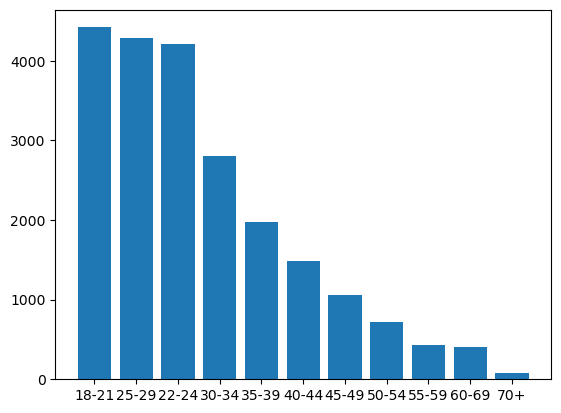

In [119]:
from matplotlib.pyplot import show
#distributie python pe categorii de varsta

from matplotlib.pyplot import hist,bar

def distributie_py_age(fileName):
    df = pd.read_csv(fileName, low_memory=False, skiprows=[1])
    columns_needed = df[['Q1', 'Q7_Part_1']]
    filtered = columns_needed[columns_needed['Q7_Part_1'] == 'Python']
    dictionar = filtered['Q1'].value_counts()
    
    bar(dictionar.index, dictionar.values)
    
distributie_py_age("data/surveyDataSience.csv")
    

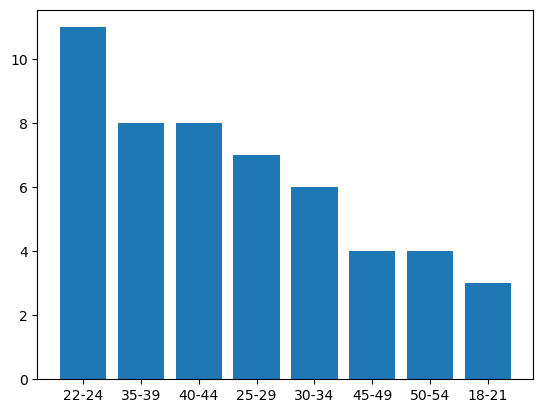

In [121]:
#same thing dar romani

def distributie_py_age_romani(fileName):
    df = pd.read_csv(fileName, low_memory=False, skiprows=[1])
    columns_needed = df[['Q1', 'Q3', 'Q7_Part_1']]
    filtered = columns_needed[(columns_needed['Q7_Part_1'] == 'Python') & (columns_needed['Q3']=='Romania')]
    dictionar = filtered['Q1'].value_counts()
    
    bar(dictionar.index, dictionar.values)

distributie_py_age_romani("data/surveyDataSience.csv")

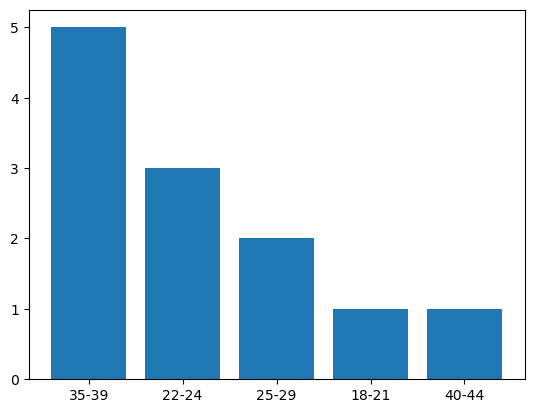

In [122]:
#femei romania

def distributie_py_age_romani_femei(fileName):
    df = pd.read_csv(fileName, low_memory=False, skiprows=[1])
    columns_needed = df[['Q1', 'Q2', 'Q3', 'Q7_Part_1']]
    filtered = columns_needed[
        (columns_needed['Q7_Part_1'] == 'Python') & 
        (columns_needed['Q3'] == 'Romania') & 
        (columns_needed['Q2']=='Woman')
    ]
    dictionar = filtered['Q1'].value_counts()
    
    bar(dictionar.index, dictionar.values)
    
distributie_py_age_romani_femei("data/surveyDataSience.csv")

Q1 (25%)       : 2.0
Q3 (75%)       : 7.5
IQR            : 5.5
Lower bound    : -6.25
Upper bound    : 15.75
Nr. outlieri   : 1860
Valori outlieri: [np.float64(30.0)]


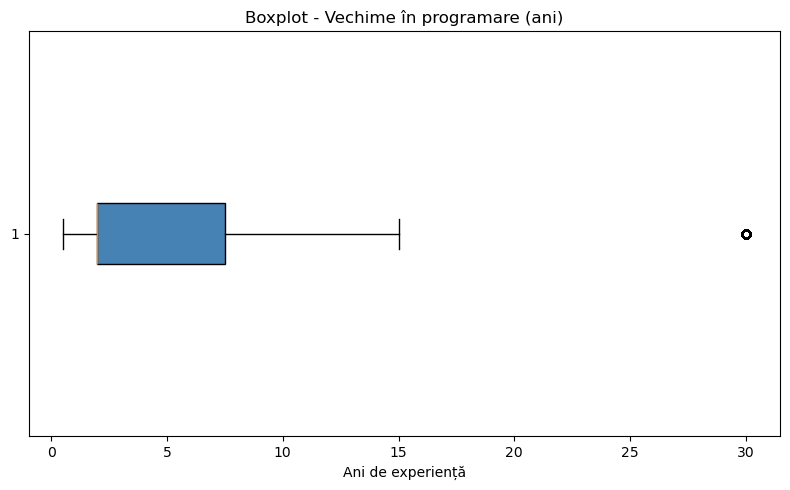

In [123]:
def outlieri_vechime(fileName):
    df = pd.read_csv(fileName, low_memory=False, skiprows=[1])

    dict_vechime = {
        '< 1 years':   0.5,
        '1-3 years':   2,
        '3-5 years':   4,
        '5-10 years':  7.5,
        '10-20 years': 15,
        '20+ years':   30
    }

    vechime = df['Q6'].map(dict_vechime).dropna()

    # IQR method to find outliers
    Q1 = vechime.quantile(0.25)
    Q3 = vechime.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlieri = vechime[(vechime < lower) | (vechime > upper)]

    print(f"Q1 (25%)       : {Q1}")
    print(f"Q3 (75%)       : {Q3}")
    print(f"IQR            : {IQR}")
    print(f"Lower bound    : {lower}")
    print(f"Upper bound    : {upper}")
    print(f"Nr. outlieri   : {len(outlieri)}")
    print(f"Valori outlieri: {sorted(outlieri.unique())}")

    # Boxplot
    plt.figure(figsize=(8, 5))
    plt.boxplot(vechime, vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", color="black"))
    plt.title("Boxplot - Vechime în programare (ani)")
    plt.xlabel("Ani de experiență")
    plt.tight_layout()
    plt.show()

outlieri_vechime("data/surveyDataSience.csv")

In [ ]:
#PROBLEMA 2

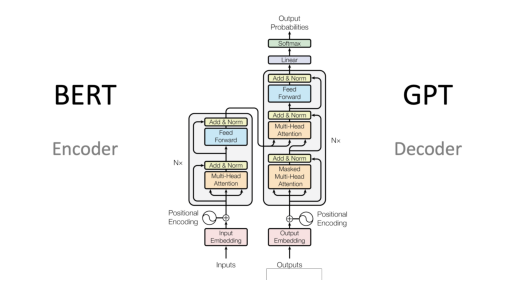

In [125]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("data/images/BERT.png")
plt.imshow(img)
plt.axis("off")  
plt.show()  

S-au găsit 12 imagini


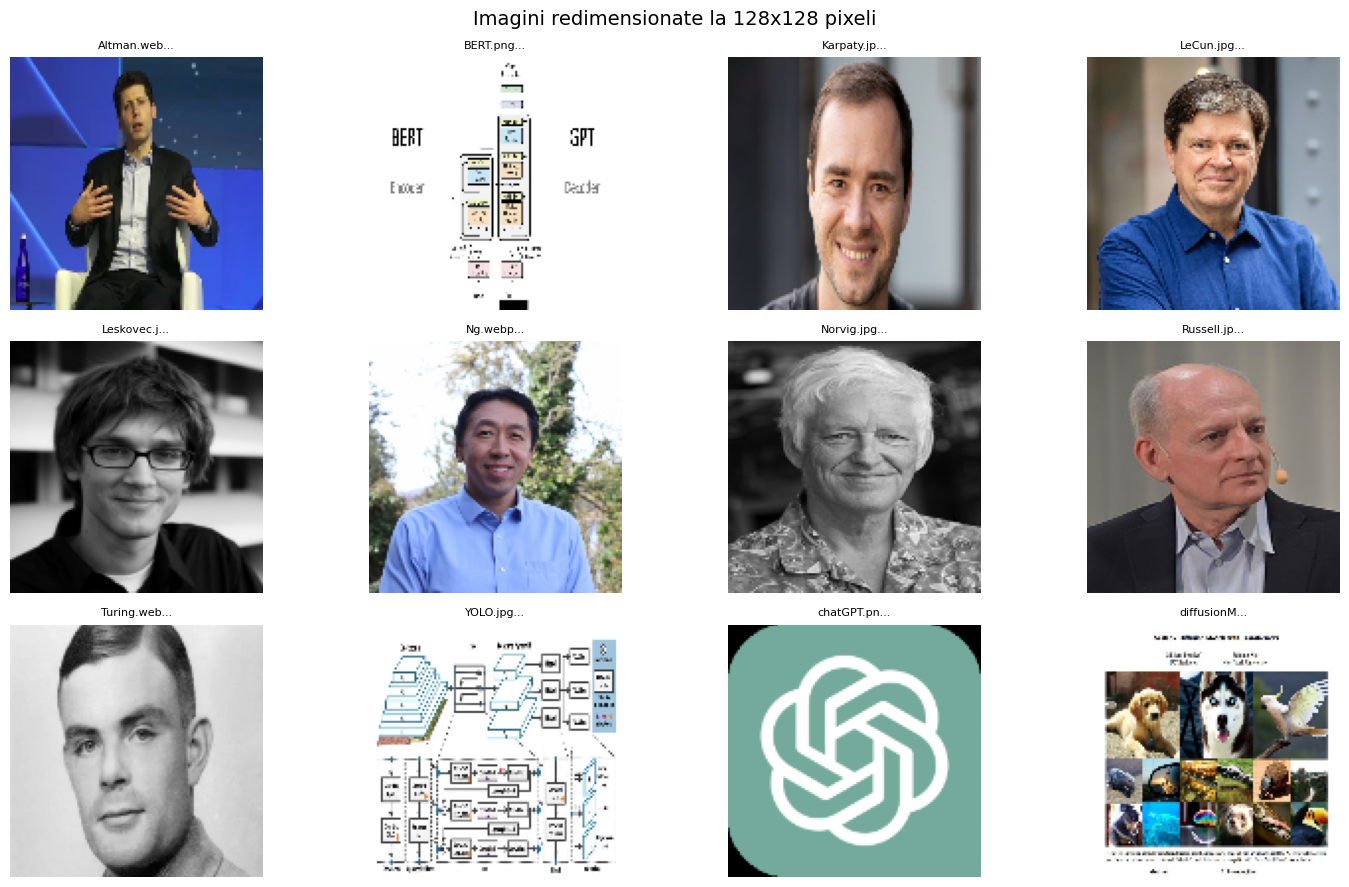

[array([[[ 47,  53, 154],
         [ 48,  55, 155],
         [ 49,  56, 156],
         ...,
         [ 29,  50,  75],
         [ 29,  50,  75],
         [ 29,  50,  75]],
 
        [[ 47,  53, 154],
         [ 48,  55, 155],
         [ 49,  56, 156],
         ...,
         [ 29,  50,  75],
         [ 29,  50,  75],
         [ 29,  50,  75]],
 
        [[ 47,  53, 154],
         [ 48,  55, 155],
         [ 49,  56, 156],
         ...,
         [ 30,  51,  76],
         [ 30,  51,  76],
         [ 30,  51,  76]],
 
        ...,
 
        [[ 57,  72, 137],
         [ 59,  73, 139],
         [ 57,  74, 139],
         ...,
         [ 39,  40, 151],
         [ 42,  39, 146],
         [ 41,  38, 145]],
 
        [[ 62,  87, 186],
         [ 63,  88, 187],
         [ 62,  87, 186],
         ...,
         [ 38,  38, 137],
         [ 39,  39, 139],
         [ 33,  40, 138]],
 
        [[ 62,  87, 186],
         [ 63,  88, 189],
         [ 62,  86, 188],
         ...,
         [ 35,  58, 163],
  

In [130]:
def redimensionare_simpla(director_imagini):
    import os
    import cv2
    import matplotlib.pyplot as plt
    
    imagini = []
    for file in os.listdir(director_imagini):
        if file.lower().endswith(('.png', '.jpg', '.webp')):
            imagini.append(os.path.join(director_imagini, file))
    
    imagini.sort()
    print(f"S-au găsit {len(imagini)} imagini")
    
    
    imagini_redimensionate = []
    nume_imagini = []
    
    for cale in imagini:
        img = cv2.imread(cale)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_redim = cv2.resize(img_rgb, (128, 128))
            imagini_redimensionate.append(img_redim)
            nume_imagini.append(os.path.basename(cale))
    
    
    n = len(imagini_redimensionate)
    cols = 4
    rows = (n + cols - 1) // cols
    
    fig = plt.figure(figsize=(15, rows * 3))
    
    for i, (img, nume) in enumerate(zip(imagini_redimensionate, nume_imagini)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(nume[:10] + "...", fontsize=8)
        plt.axis('off')
    
    plt.suptitle(f"Imagini redimensionate la 128x128 pixeli", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return imagini_redimensionate

redimensionare_simpla("data/images")

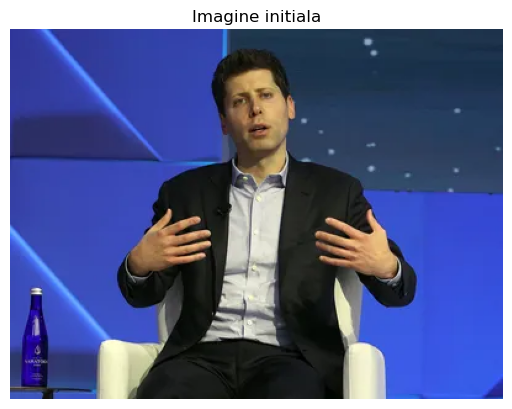

In [133]:
import cv2
import os
import matplotlib.pyplot as plt

folder = "data/images"

files = os.listdir(folder)
img_path = os.path.join(folder, files[0])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Imagine initiala")
plt.axis("off")
plt.show()

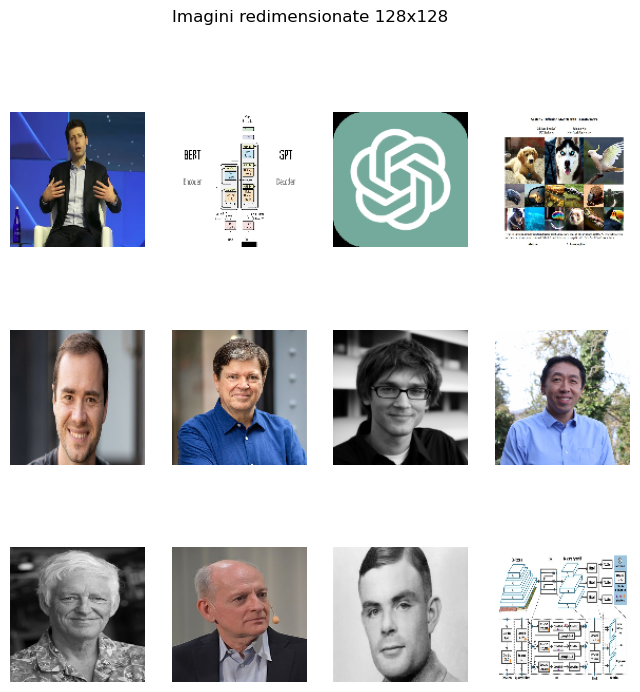

In [134]:
import cv2
import os
import matplotlib.pyplot as plt
images = []

for file in files:
    path = os.path.join(folder, file)
    img = cv2.imread(path)

    img = cv2.resize(img, (128,128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    images.append(img)

cols = 4
rows = (len(images)+cols-1)//cols

plt.figure(figsize=(8,8))

for i, img in enumerate(images):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Imagini redimensionate 128x128")
plt.show()

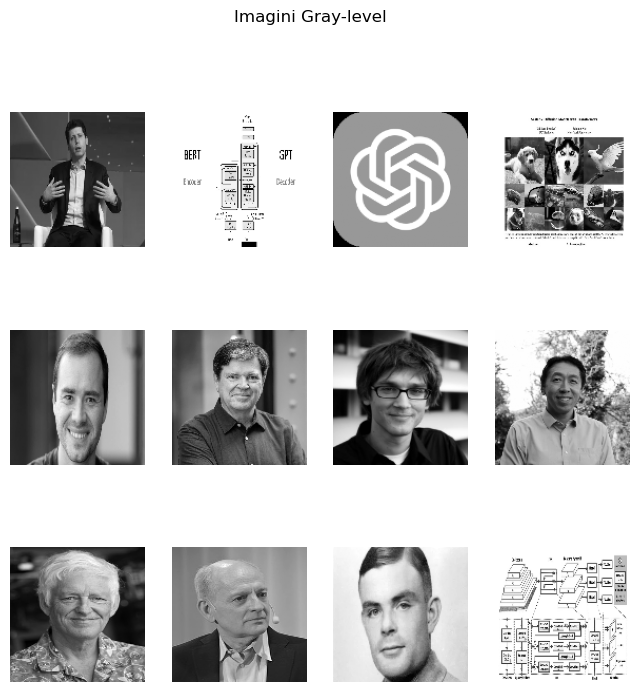

In [135]:
gray_images = []

for file in files:
    path = os.path.join(folder, file)
    img = cv2.imread(path)
    img = cv2.resize(img,(128,128))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray)

plt.figure(figsize=(8,8))

for i, img in enumerate(gray_images):
    plt.subplot(rows, cols, i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

plt.suptitle("Imagini Gray-level")
plt.show()

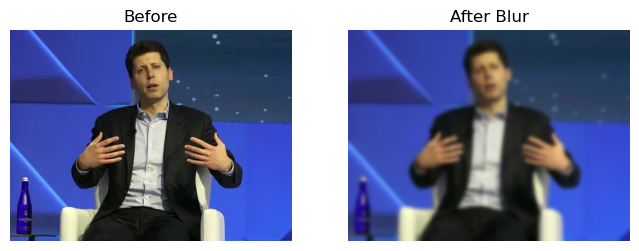

In [136]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

blur = cv2.GaussianBlur(img,(15,15),0)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Before")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blur)
plt.title("After Blur")
plt.axis("off")

plt.show()

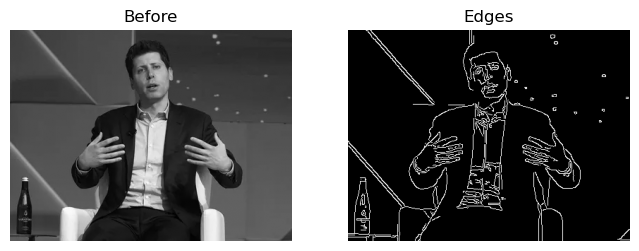

In [137]:
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,100,200)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap="gray")
plt.title("Before")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Edges")
plt.axis("off")

plt.show()

In [ ]:
#PROBLEMA 3

In [141]:
def citeste_text(fisier):
    with open(fisier, 'r', encoding='utf_8') as f:
        text = f.read()
    return text
    
print(citeste_text("data/texts.txt"))

Mesaj de informare: 
Cursul și laboratoarele de Inteligență Artificială vor fi o 
provocare pentru toți. Suntem convinși că veți realiza proiecte 
foarte interesante. Vă încurajăm să adresați întrebări atunci 
când ceva nu e clar, atât în mod live, cât și folosind platforma 
Teams, canalul ”general”. 
Dacă ați citit până aici, vă rugăm să lăsați un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm că am citit 
textul pentru problema 3 din lab2”. 
--
Mesaj de informare generat de ChatGPT:
Stimați cursanți,
Suntem încântați să vă avem în echipa noastră pentru Cursul și 
laboratoarele de Inteligență Artificială. Această experiență va 
fi o adevărată provocare, dar suntem convinși că veți realiza 
proiecte extrem de interesante.
Vă încurajăm să fiți activi și să adresați întrebări atunci când 
ceva nu este clar. Fie că este vorba de o discuție în timp real 
sau prin intermediul platformei Teams, canalul ”general”, suntem 
aici să vă sprijinim.
Succes și să înceapă ave

In [144]:
import re

def nr_propozitii(text):
    propozitii = re.split(r'[.!]|--', text)
    propozitii = [p.strip() for p in propozitii if p.strip()]
    return len(propozitii)

text = citeste_text("data/texts.txt")
print(f"propoziții: {nr_propozitii(text)}")

Număr propoziții: 10


In [145]:
def nr_cuvinte(text):
    cuvinte = re.findall(r'\b\w+\b', text)
    return len(cuvinte)

text = citeste_text("data/texts.txt")
print(f"cuvinte: {nr_cuvinte(text)}")


Număr cuvinte: 160


In [147]:
def nr_cuvinte_diferite(text):
    cuvinte = re.findall(r'\b\w+\b', text)
    return len(set(cuvinte))

text = citeste_text("data/texts.txt")
print(f"cuvinte diferite: {nr_cuvinte_diferite(text)}")


Număr cuvinte diferite: 97


In [149]:
def cuvant_min_max(text):
    cuvinte = re.findall(r'\b\w+\b', text)
    min_cuv = min(cuvinte, key=len)
    max_cuv = max(cuvinte, key=len)
    return min_cuv, max_cuv

text = citeste_text("data/texts.txt")
min_cuv, max_cuv = cuvant_min_max(text)
print(f"cel mai scurt: {min_cuv}")
print(f"cel mai lung: {max_cuv}")

cel mai scurt: o
cel mai lung: Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm


In [152]:
def fara_diacritice(text):
    dict = {
        'ă': 'a',
        'Ă': 'A',
        'î': 'i',
        'Î': 'I',
        'â': 'a',
        'Â': 'A',
        'ș': 's',
        'Ș': 'S',
        'ț': 't',
        'Ț': 'T'
    }
    for old, new in dict.items():
        text = text.replace(old, new)
    return text

text = citeste_text("data/texts.txt")
print(fara_diacritice(text))

Mesaj de informare: 
Cursul si laboratoarele de Inteligenta Artificiala vor fi o 
provocare pentru toti. Suntem convinsi ca veti realiza proiecte 
foarte interesante. Va incurajam sa adresati intrebari atunci 
cand ceva nu e clar, atat in mod live, cat si folosind platforma 
Teams, canalul ”general”. 
Daca ati citit pana aici, va rugam sa lasati un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm ca am citit 
textul pentru problema 3 din lab2”. 
--
Mesaj de informare generat de ChatGPT:
Stimati cursanti,
Suntem incantati sa va avem in echipa noastra pentru Cursul si 
laboratoarele de Inteligenta Artificiala. Aceasta experienta va 
fi o adevarata provocare, dar suntem convinsi ca veti realiza 
proiecte extrem de interesante.
Va incurajam sa fiti activi si sa adresati intrebari atunci cand 
ceva nu este clar. Fie ca este vorba de o discutie in timp real 
sau prin intermediul platformei Teams, canalul ”general”, suntem 
aici sa va sprijinim.
Succes si sa inceapa ave

In [155]:
import requests

def sinonime_cuvant(cuvant):
    url = f"https://api.datamuse.com/words?rel_syn={cuvant}"
    response = requests.get(url)
    data = response.json()
    sinonime = [item["word"] for item in data]
    print(f"Sinonime pentru '{cuvant}': {sinonime}")
    return sinonime

sinonime_cuvant("confirm")

Sinonime pentru 'confirm': ['sustain', 'affirm', 'support', 'corroborate', 'substantiate', 'reassert']


['sustain', 'affirm', 'support', 'corroborate', 'substantiate', 'reassert']

In [182]:
import requests

def cuvant_corectat(cuvant):
    url = "https://api.languagetool.org/v2/check"
    
    params = {
        'text': cuvant,
        'language': 'ro'
    }
    
    try:
        response = requests.post(url, data=params)
        response.raise_for_status() 
        
        result = response.json()
        
        if result['matches']:
            for match in result['matches']:
                sugestii = [s['value'] for s in match['replacements']]
                if sugestii:
                    #print(f"sugestii: {', '.join(sugestii[:5])}")
                    return sugestii[0]
        else:
            return cuvant
            
    except requests.exceptions.RequestException as e:
        print(f"Eroare de conexiune: {e}")
        return None
    except KeyError as e:
        print(f"Eroare la procesare: {e}")
        return None

cuvant = "confiiiirm"
sugestie = cuvant_corectat(cuvant)

print(sugestie)

confirm


In [191]:
def delete_insane_letters(cuvant):
     return re.sub(r'(.)\1{3,}', r'\1\1\1', cuvant)

print(delete_insane_letters('confiiiiiiiiirm'))

confiiirm


In [193]:
from bs4 import BeautifulSoup


def sinonim(cuvant):
    headers = {"User-Agent": "Mozilla/5.0"}
    session = requests.Session()
    session.get("https://www.dictionardesinonime.ro/", headers=headers)
    response = session.get(f"https://www.dictionardesinonime.ro/?c={cuvant}", headers=headers)

    soup = BeautifulSoup(response.text, "html.parser")
    
    # Synonyms are inside div.content_page_simple → first span.def
    div = soup.find("div", class_="content_page_simple")
    span = div.find("span", class_="def")

    sinonime = list(set([a.text.strip() for a in span.find_all("a")]))
    #print(f"Sinonime pentru '{cuvant}': {sinonime}")
    return sinonime


text = citeste_text("data/texts.txt")
cuv_max = cuvant_min_max(text)[1]
cuv = delete_insane_letters(cuv_max)
corect = cuvant_corectat(cuv)

print(sinonim(corect))

    

['consfinţi', 'adeveri', 'arăta', 'mărturi', 'dovedi', 'certifica', 'atesta', 'valida', 'ratifica', 'recunoaşte', 'stabili', 'sprijini', 'întări', 'sancţiona', 'susţine', 'probălui', 'demonstra', 'mărturisi', 'proba', 'corobora', 'încredinţa', 'consacra']


In [ ]:
#PROBLEMA 4


Numar respondenti cu date complete: 23974

domenii originale:
  Durata studii: [3.0, 8.0]
  Vechime programare: [0.5, 25.0]


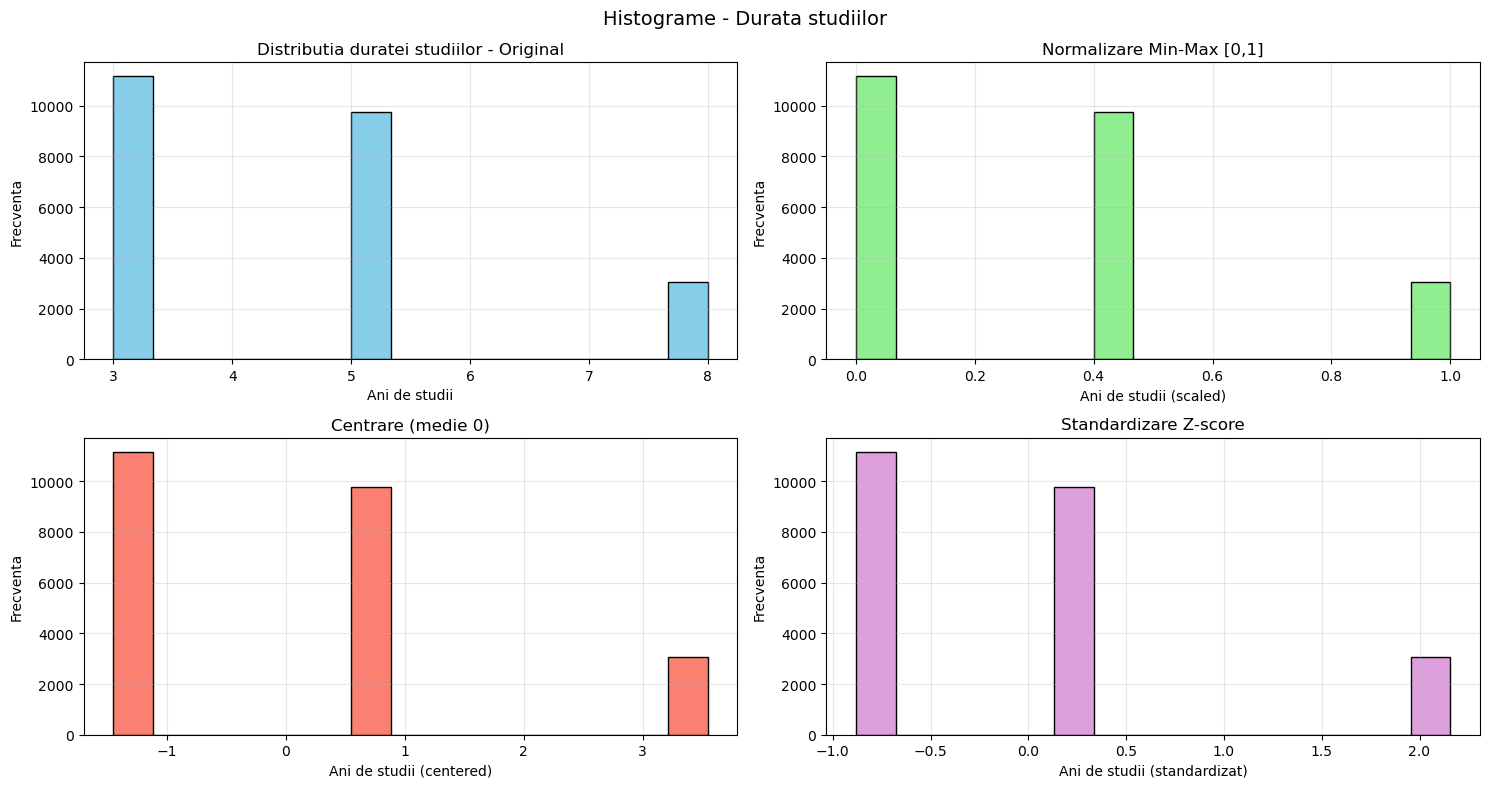

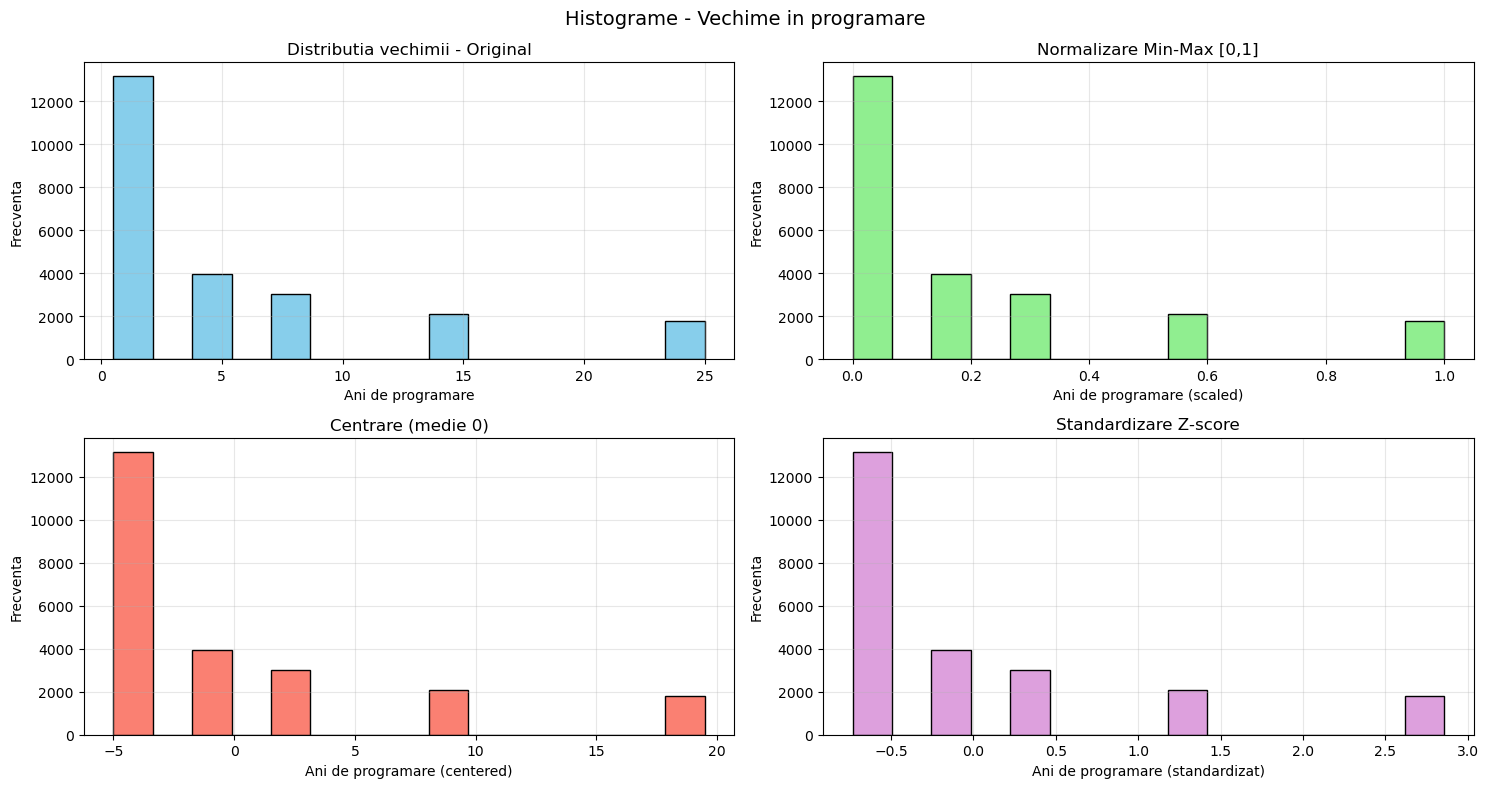

In [202]:
import csv
import matplotlib.pyplot as plt
from statistics import mean, stdev
import os

def loadDataMoreInputs(fileName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    return dataNames, data

def extractFeature(allData, names, featureName):
    if featureName not in names:
        print(f"Coloana {featureName} nu exista!")
        return []
    pos = names.index(featureName)
    values = []
    for data_row in allData:
        try:
            if data_row[pos] and data_row[pos].strip():
                values.append(data_row[pos])
        except IndexError:
            continue
    return values

def converteste_studii_ani(educatie):
    if not educatie:
        return None
    educatie = str(educatie).lower()
    if 'bachelor' in educatie:
        return 3
    elif 'master' in educatie:
        return 5
    elif 'doctoral' in educatie or 'phd' in educatie:
        return 8
    elif 'professional' in educatie:
        return 8
    elif 'some college' in educatie:
        return 1
    else:
        return None

def converteste_vechime_ani(vechime):
    if not vechime:
        return None
    vechime = str(vechime).lower()
    if '< 1' in vechime:
        return 0.5
    elif '1-3 years' in vechime:
        return 2
    elif '3-5 years' in vechime:
        return 4
    elif '5-10 years' in vechime:
        return 7.5
    elif '10-20 years' in vechime:
        return 15
    elif '20+ years' in vechime:
        return 25
    else:
        try:
            return float(vechime)
        except:
            return None

def scale01(features):
    if not features:
        return []
    minFeat = min(features)
    maxFeat = max(features)
    return [(feat - minFeat) / (maxFeat - minFeat) for feat in features]

def zeroCentralisation(features):
    if not features:
        return []
    meanValue = mean(features)
    return [feat - meanValue for feat in features]

def statisticalNormalisation(features):
    if not features:
        return []
    meanValue = mean(features)
    stdDevValue = stdev(features)
    return [(feat - meanValue) / stdDevValue for feat in features]

def normalizeaza_problema1():
    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, 'data', 'surveyDataSience.csv')
    
    names, allData = loadDataMoreInputs(filePath)
    
    
    educatie_raw = extractFeature(allData, names, 'Q4')
    vechime_raw = extractFeature(allData, names, 'Q6')
    
    
    studii_ani = []
    vechime_ani = []
    
    for i in range(min(len(educatie_raw), len(vechime_raw))):
        ani_studii = converteste_studii_ani(educatie_raw[i])
        ani_vechime = converteste_vechime_ani(vechime_raw[i])
        
        if ani_studii is not None and ani_vechime is not None:
            studii_ani.append(ani_studii)
            vechime_ani.append(ani_vechime)
    
    print(f"\nNumar respondenti cu date complete: {len(studii_ani)}")
    
    if not studii_ani or not vechime_ani:
        print("Nu s-au putut extrage date!")
        return
    
    print(f"\ndomenii originale:")
    print(f"  Durata studii: [{min(studii_ani):.1f}, {max(studii_ani):.1f}]")
    print(f"  Vechime programare: [{min(vechime_ani):.1f}, {max(vechime_ani):.1f}]")
    
    studii_scaled = scale01(studii_ani)
    vechime_scaled = scale01(vechime_ani)
    
    studii_centered = zeroCentralisation(studii_ani)
    vechime_centered = zeroCentralisation(vechime_ani)
    
    studii_norm = statisticalNormalisation(studii_ani)
    vechime_norm = statisticalNormalisation(vechime_ani)
    
    # Histograme pentru durata studiilor
    plt.figure(figsize=(15, 8))
    
    plt.subplot(2, 2, 1)
    plt.hist(studii_ani, bins=15, edgecolor='black', color='skyblue')
    plt.xlabel('Ani de studii')
    plt.ylabel('Frecventa')
    plt.title('Distributia duratei studiilor - Original')
    plt.grid(alpha=0.3)
    
    plt.subplot(2, 2, 2)
    plt.hist(studii_scaled, bins=15, edgecolor='black', color='lightgreen')
    plt.xlabel('Ani de studii (scaled)')
    plt.ylabel('Frecventa')
    plt.title('Normalizare Min-Max [0,1]')
    plt.grid(alpha=0.3)
    
    plt.subplot(2, 2, 3)
    plt.hist(studii_centered, bins=15, edgecolor='black', color='salmon')
    plt.xlabel('Ani de studii (centered)')
    plt.ylabel('Frecventa')
    plt.title('Centrare (medie 0)')
    plt.grid(alpha=0.3)
    
    plt.subplot(2, 2, 4)
    plt.hist(studii_norm, bins=15, edgecolor='black', color='plum')
    plt.xlabel('Ani de studii (standardizat)')
    plt.ylabel('Frecventa')
    plt.title('Standardizare Z-score')
    plt.grid(alpha=0.3)
    
    plt.suptitle('Histograme - Durata studiilor', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Histograme pentru vechimea in programare
    plt.figure(figsize=(15, 8))
    
    plt.subplot(2, 2, 1)
    plt.hist(vechime_ani, bins=15, edgecolor='black', color='skyblue')
    plt.xlabel('Ani de programare')
    plt.ylabel('Frecventa')
    plt.title('Distributia vechimii - Original')
    plt.grid(alpha=0.3)
    
    plt.subplot(2, 2, 2)
    plt.hist(vechime_scaled, bins=15, edgecolor='black', color='lightgreen')
    plt.xlabel('Ani de programare (scaled)')
    plt.ylabel('Frecventa')
    plt.title('Normalizare Min-Max [0,1]')
    plt.grid(alpha=0.3)
    
    plt.subplot(2, 2, 3)
    plt.hist(vechime_centered, bins=15, edgecolor='black', color='salmon')
    plt.xlabel('Ani de programare (centered)')
    plt.ylabel('Frecventa')
    plt.title('Centrare (medie 0)')
    plt.grid(alpha=0.3)
    
    plt.subplot(2, 2, 4)
    plt.hist(vechime_norm, bins=15, edgecolor='black', color='plum')
    plt.xlabel('Ani de programare (standardizat)')
    plt.ylabel('Frecventa')
    plt.title('Standardizare Z-score')
    plt.grid(alpha=0.3)
    
    plt.suptitle('Histograme - Vechime in programare', fontsize=14)
    plt.tight_layout()
    plt.show()

normalizeaza_problema1()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6931922..1.0025903].



📸 PROBLEMA 2 - Normalizare imagini

🖼️ Imagine 1: diffusionModel.jpg
  Dimensiuni originale: (755, 637)
  Statistici originale - min: 0, max: 255, medie: 160.16
  Min-Max - min: 0.000, max: 1.000
  Z-score - min: -1.693, max: 1.003, medie: -0.000


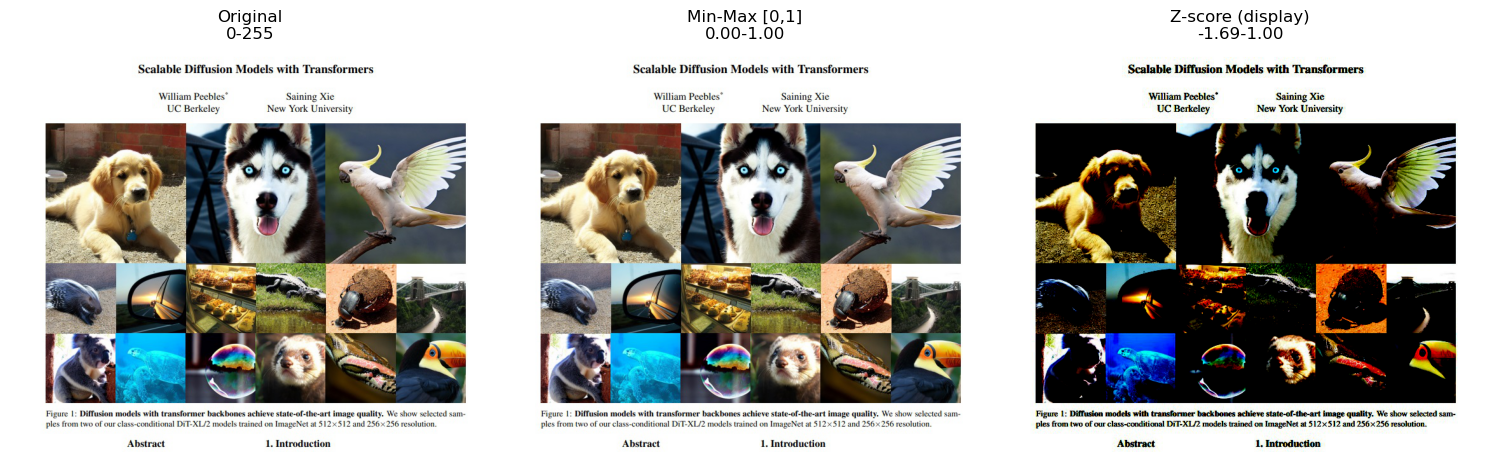

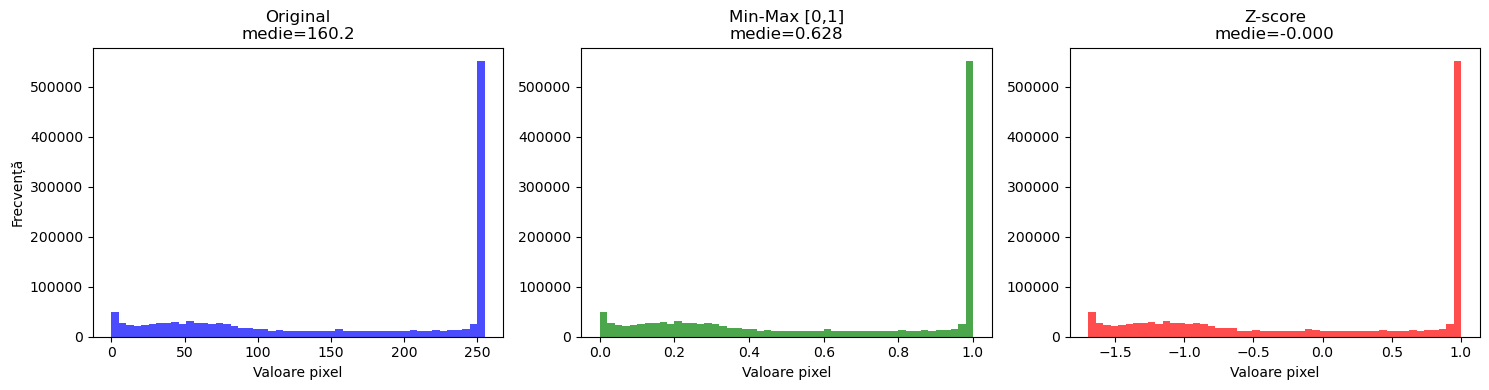

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.741872..2.317641].



🖼️ Imagine 2: Karpaty.jpg
  Dimensiuni originale: (800, 489)
  Statistici originale - min: 0, max: 255, medie: 109.42
  Min-Max - min: 0.000, max: 1.000
  Z-score - min: -1.742, max: 2.318, medie: -0.000


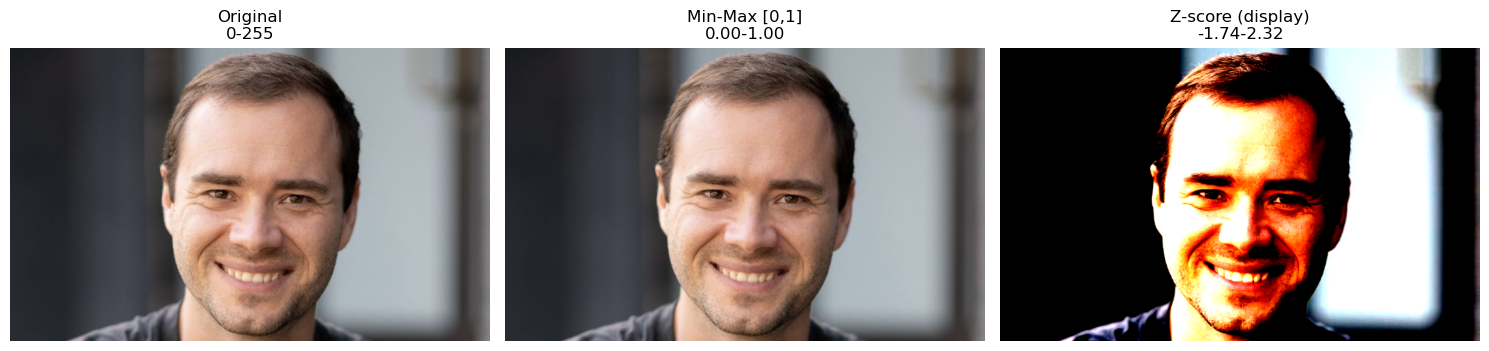

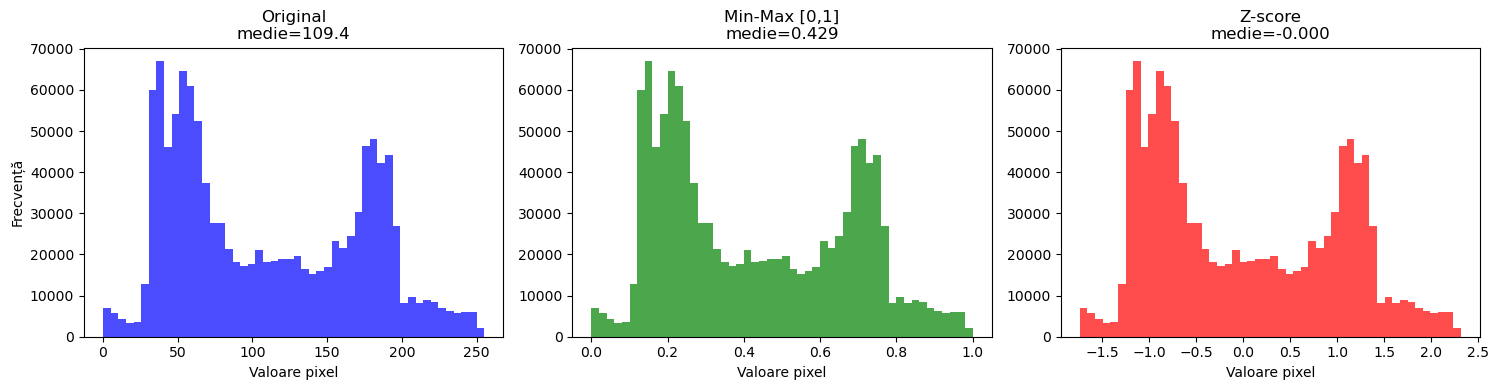

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9621654..2.5278847].



🖼️ Imagine 3: LeCun.jpg
  Dimensiuni originale: (1461, 1461)
  Statistici originale - min: 0, max: 255, medie: 111.44
  Min-Max - min: 0.000, max: 1.000
  Z-score - min: -1.962, max: 2.528, medie: 0.000


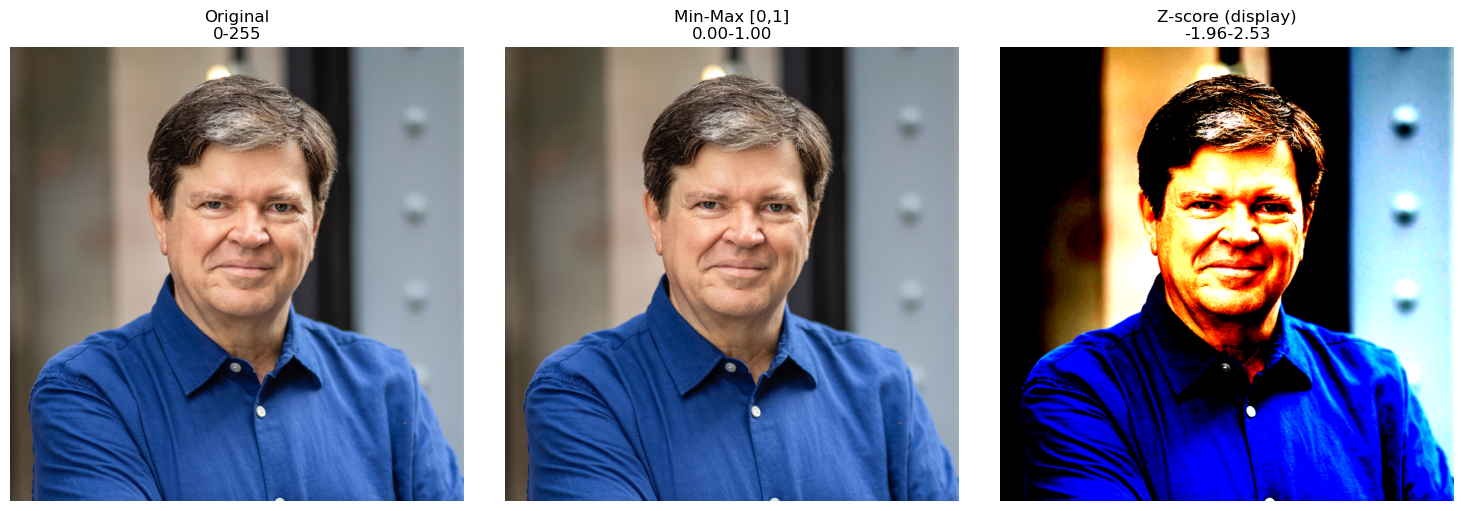

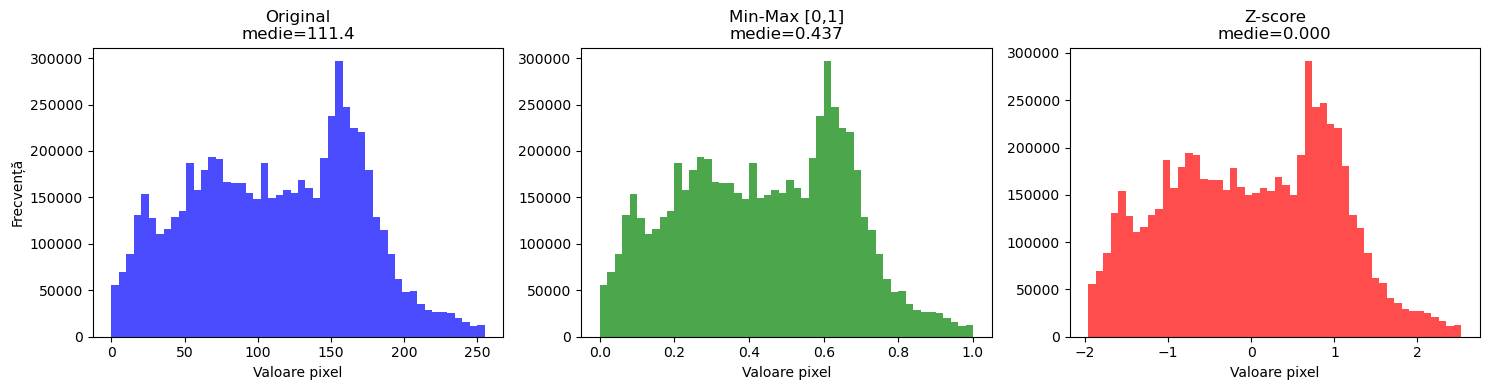

In [4]:
from PIL import Image
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

def normalizeaza_imagine_minmax(imagine):
    img_array = np.array(imagine).astype(np.float32)
    if img_array.max() > 1.0:
        img_normalizata = img_array / 255.0
    else:
        img_normalizata = img_array
    return img_normalizata  # Returnează array, nu imagine

def normalizeaza_imagine_zscore(imagine):
    img_array = np.array(imagine).astype(np.float32)
    mean = img_array.mean()
    std = img_array.std()
    
    if std > 0:
        img_normalizata = (img_array - mean) / std
    else:
        img_normalizata = img_array
    
    return img_normalizata  

def proceseaza_imagini_problema2():
    print("\n" + "="*60)
    print("📸 PROBLEMA 2 - Normalizare imagini")
    print("="*60)
    
    director_imagini = 'data/images/'
    if not os.path.exists(director_imagini):
        print(f"Directorul {director_imagini} nu există!")
        return
    
    imagini = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.webp']:
        imagini.extend(glob.glob(os.path.join(director_imagini, ext)))
    
    if len(imagini) == 0:
        print("Nu există imagini în director!")
        return
    
    for i, img_path in enumerate(imagini[:3]):
        print(f"\n🖼️ Imagine {i+1}: {os.path.basename(img_path)}")
        
        img = Image.open(img_path)
        img_array = np.array(img)
        
        print(f"  Dimensiuni originale: {img.size}")
        print(f"  Statistici originale - min: {img_array.min()}, max: {img_array.max()}, medie: {img_array.mean():.2f}")
        
        img_minmax = normalizeaza_imagine_minmax(img)
        img_zscore = normalizeaza_imagine_zscore(img)
        
        print(f"  Min-Max - min: {img_minmax.min():.3f}, max: {img_minmax.max():.3f}")
        print(f"  Z-score - min: {img_zscore.min():.3f}, max: {img_zscore.max():.3f}, medie: {img_zscore.mean():.3f}")
        
        # Afișare imagini (pentru vizualizare, Z-score trebuie adus înapoi în [0,1])
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(img)
        axes[0].set_title(f'Original\n{img_array.min()}-{img_array.max()}')
        axes[0].axis('off')
        
        axes[1].imshow(img_minmax, cmap='gray', vmin=0, vmax=1)
        axes[1].set_title(f'Min-Max [0,1]\n{img_minmax.min():.2f}-{img_minmax.max():.2f}')
        axes[1].axis('off')
        
        # Pentru afișare, aducem Z-score în [0,1] doar pentru vizualizare
        #img_zscore_display = (img_zscore - img_zscore.min()) / (img_zscore.max() - img_zscore.min())
        axes[2].imshow(img_zscore, cmap='gray', vmin=0, vmax=1)
        axes[2].set_title(f'Z-score (display)\n{img_zscore.min():.2f}-{img_zscore.max():.2f}')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Histograme 
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        axes[0].hist(img_array.flatten(), bins=50, color='blue', alpha=0.7)
        axes[0].set_title(f'Original\nmedie={img_array.mean():.1f}')
        axes[0].set_xlabel('Valoare pixel')
        axes[0].set_ylabel('Frecvență')
        
        axes[1].hist(img_minmax.flatten(), bins=50, color='green', alpha=0.7)
        axes[1].set_title(f'Min-Max [0,1]\nmedie={img_minmax.mean():.3f}')
        axes[1].set_xlabel('Valoare pixel')
        
        axes[2].hist(img_zscore.flatten(), bins=50, color='red', alpha=0.7)
        axes[2].set_title(f'Z-score\nmedie={img_zscore.mean():.3f}')
        axes[2].set_xlabel('Valoare pixel')
        
        plt.tight_layout()
        plt.show()

proceseaza_imagini_problema2()

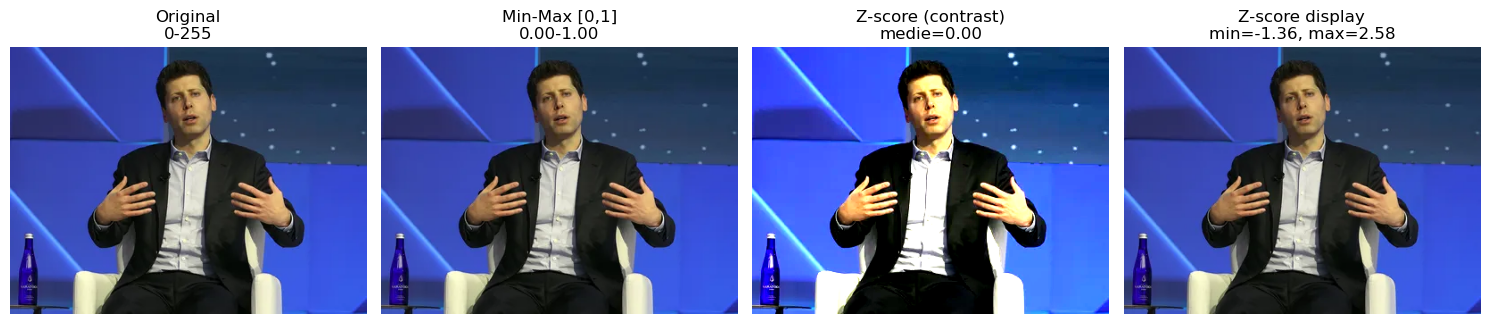

In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

folder = "data/images"
files = os.listdir(folder)
img_path = os.path.join(folder, files[0])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_float = img.astype(np.float32)

# 1. Normalizare Min-Max [0, 1]
min_val = img_float.min()
max_val = img_float.max()
img_minmax = (img_float - min_val) / (max_val - min_val)

# 2. Normalizare Z-score (valori negative și pozitive)
mean = img_float.mean()
std = img_float.std()
img_zscore = (img_float - mean) / std

# 3. Z-score adus în [0,1] DOAR pentru afișare
img_zscore_display = (img_zscore - img_zscore.min()) / (img_zscore.max() - img_zscore.min())

# Afișare
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title(f'Original\n{img.min()}-{img.max()}')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_minmax, vmin=0, vmax=1)
plt.title(f'Min-Max [0,1]\n{img_minmax.min():.2f}-{img_minmax.max():.2f}')
plt.axis('off')

plt.subplot(1, 4, 3)
# Aplică o funcție de scalare pentru a vedea efectul Z-score
# De exemplu, adăugăm contrast
img_zscore_contrast = np.clip((img_zscore * 0.5) + 0.5, 0, 1)
plt.imshow(img_zscore_contrast, vmin=0, vmax=1, cmap='gray')
plt.title(f'Z-score (contrast)\nmedie={img_zscore.mean():.2f}')
plt.axis('off')

plt.subplot(1, 4, 4)
# Sau afișăm direct Z-score cu mapare liniară
plt.imshow(img_zscore_display, vmin=0, vmax=1, cmap='viridis')
plt.title(f'Z-score display\nmin={img_zscore.min():.2f}, max={img_zscore.max():.2f}')
plt.axis('off')

plt.tight_layout()
plt.show()


📝 PROBLEMA 3 - Normalizare frecvență cuvinte
Total propoziții: 10

📌 Propoziția 1:
   Mesaj de informare: 
Cursul și laboratoarele de Inteligență Artificială vor fi o 
provocare pentru t...
   Total cuvinte: 15
   Cuvinte unice: 14
   Frecvențe originale: {'de': 2, 'mesaj': 1, 'informare': 1, 'cursul': 1, 'și': 1}

   Top 5 cuvinte - comparație metode:
   Cuvânt          Original Min-Max    TF         Log       
   -------------------------------------------------------
   de              2        1.000      0.133      1.099     
   mesaj           1        0.000      0.067      0.693     
   informare       1        0.000      0.067      0.693     
   cursul          1        0.000      0.067      0.693     
   și              1        0.000      0.067      0.693     


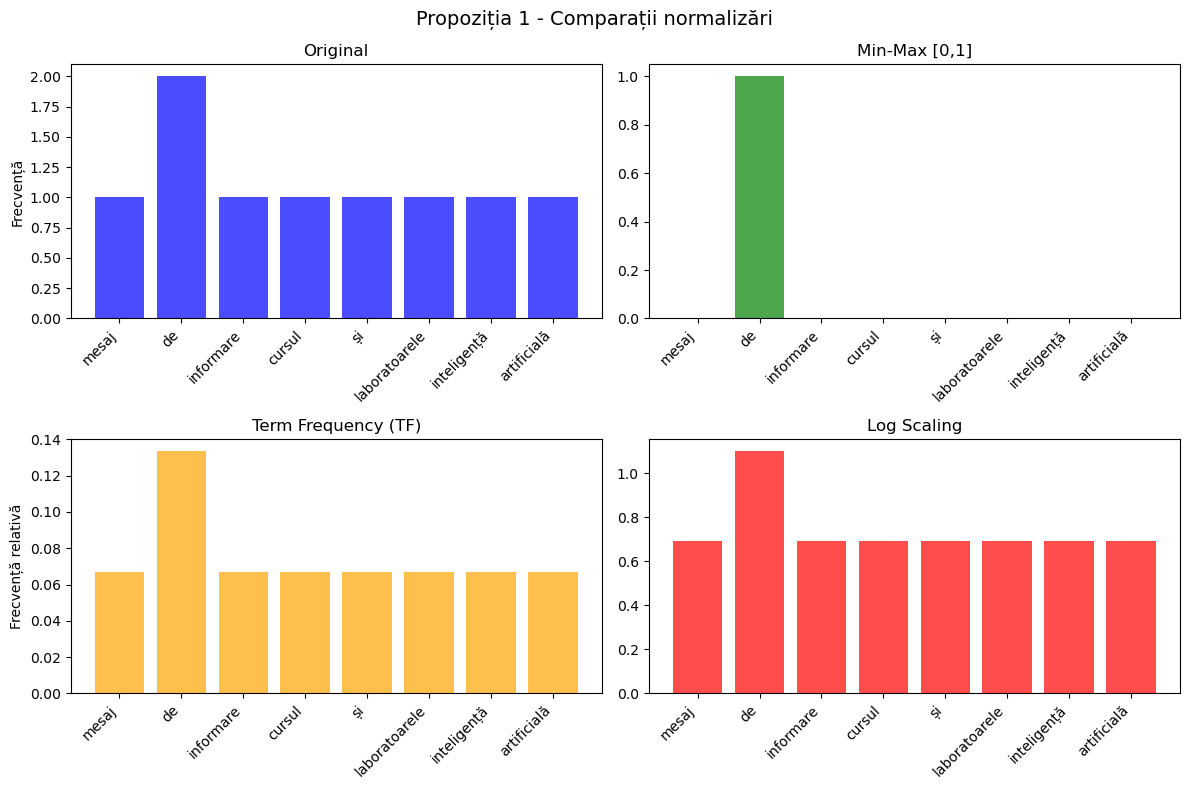


   Statistici:
     Original - min: 1, max: 2
     Min-Max  - min: 0.000, max: 1.000
     TF       - min: 0.067, max: 0.133
     Log      - min: 0.693, max: 1.099

📌 Propoziția 2:
   Suntem convinși că veți realiza proiecte 
foarte interesante
   Total cuvinte: 8
   Cuvinte unice: 8
   Frecvențe originale: {'suntem': 1, 'convinși': 1, 'că': 1, 'veți': 1, 'realiza': 1}

   Top 5 cuvinte - comparație metode:
   Cuvânt          Original Min-Max    TF         Log       
   -------------------------------------------------------
   suntem          1        0.500      0.125      0.693     
   convinși        1        0.500      0.125      0.693     
   că              1        0.500      0.125      0.693     
   veți            1        0.500      0.125      0.693     
   realiza         1        0.500      0.125      0.693     


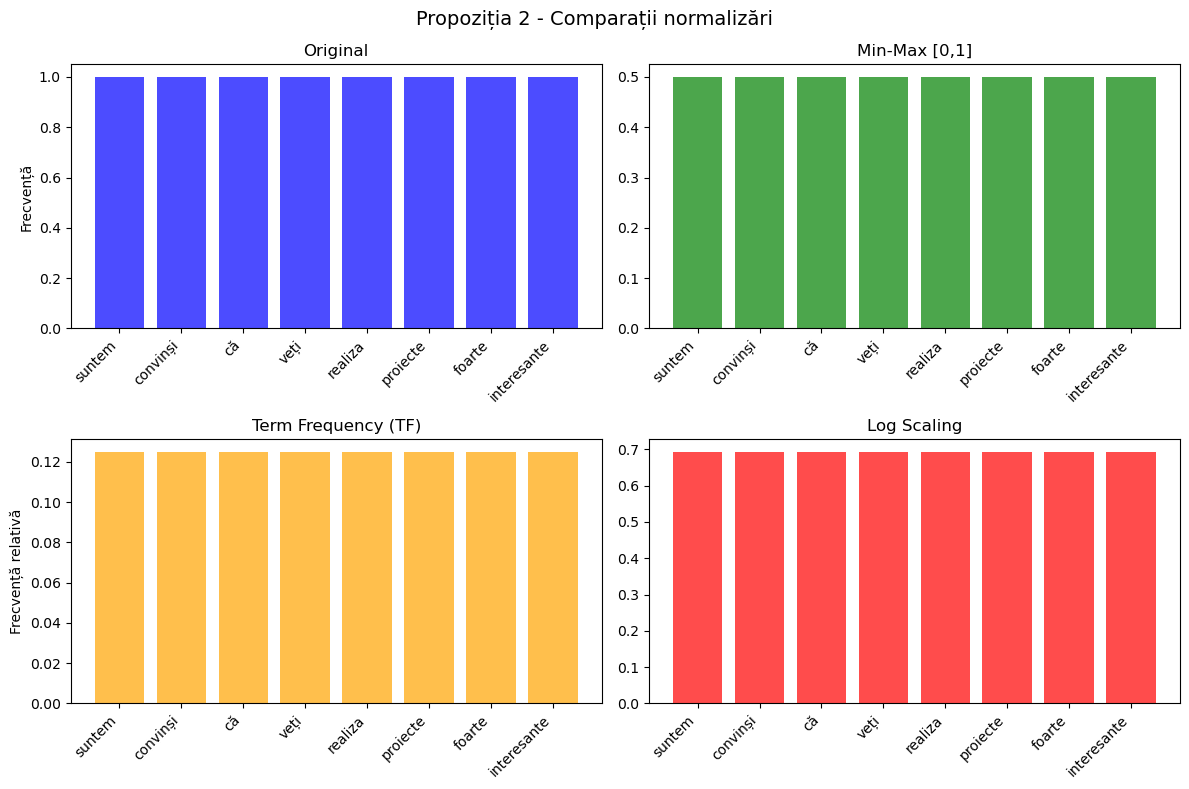


   Statistici:
     Original - min: 1, max: 1
     Min-Max  - min: 0.500, max: 0.500
     TF       - min: 0.125, max: 0.125
     Log      - min: 0.693, max: 0.693

📌 Propoziția 3:
   Vă încurajăm să adresați întrebări atunci 
când ceva nu e clar, atât în mod live, cât și folosind pl...
   Total cuvinte: 22
   Cuvinte unice: 22
   Frecvențe originale: {'vă': 1, 'încurajăm': 1, 'să': 1, 'adresați': 1, 'întrebări': 1}

   Top 5 cuvinte - comparație metode:
   Cuvânt          Original Min-Max    TF         Log       
   -------------------------------------------------------
   vă              1        0.500      0.045      0.693     
   încurajăm       1        0.500      0.045      0.693     
   să              1        0.500      0.045      0.693     
   adresați        1        0.500      0.045      0.693     
   întrebări       1        0.500      0.045      0.693     


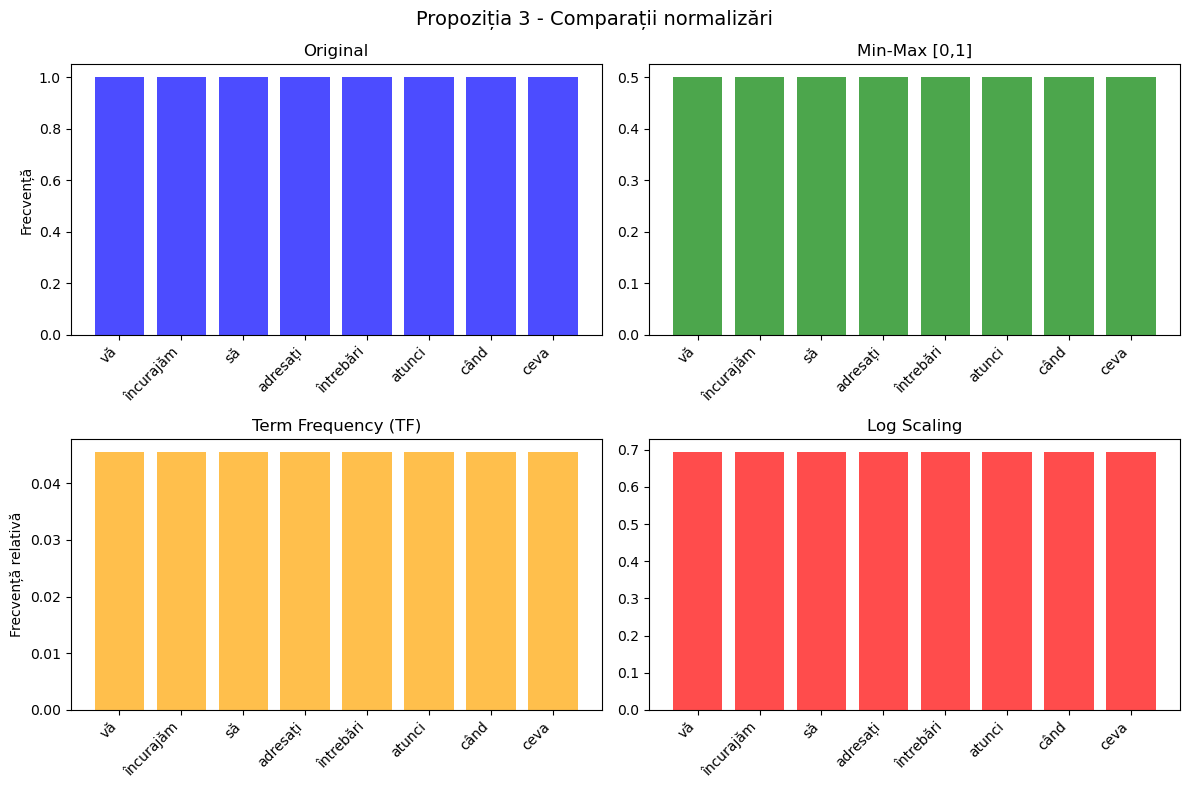


   Statistici:
     Original - min: 1, max: 1
     Min-Max  - min: 0.500, max: 0.500
     TF       - min: 0.045, max: 0.045
     Log      - min: 0.693, max: 0.693


In [2]:
import re
from collections import Counter
import math
import matplotlib.pyplot as plt
import numpy as np

def citeste_text(fisier):
    with open(fisier, 'r', encoding='utf-8') as f:
        return f.read()

def normalizeaza_frecventa_minmax(frecvente):
    """Normalizare Min-Max frecv"""
    valori = list(frecvente.values())
    if not valori:
        return {}
    
    min_val = min(valori)
    max_val = max(valori)
    
    if max_val == min_val:
        return {cuv: 0.5 for cuv in frecvente}
    
    return {cuv: (val - min_val) / (max_val - min_val) for cuv, val in frecvente.items()}

def normalizeaza_frecventa_tf(frecvente):
    """Term Frequency frecv relativa"""
    total = sum(frecvente.values())
    if total == 0:
        return {}
    return {cuv: val / total for cuv, val in frecvente.items()}

def normalizeaza_frecventa_log(frecvente):
    """Log scaling - log(1 + freq)"""
    return {cuv: math.log1p(val) for cuv, val in frecvente.items()}

def proceseaza_problema3():
    print("\n" + "="*60)
    print("📝 PROBLEMA 3 - Normalizare frecvență cuvinte")
    print("="*60)
    
    text = citeste_text('data/texts.txt')
    
    propozitii = re.split(r'[.!?]+', text)
    propozitii = [p.strip() for p in propozitii if p.strip()]
    
    print(f"Total propoziții: {len(propozitii)}")
    
    for i, propozitie in enumerate(propozitii[:3]):
        print(f"\n📌 Propoziția {i+1}:")
        print(f"   {propozitie[:100]}..." if len(propozitie) > 100 else f"   {propozitie}")
        
        cuvinte = re.findall(r'\b\w+\b', propozitie.lower())
        frecventa = Counter(cuvinte)
        
        print(f"   Total cuvinte: {len(cuvinte)}")
        print(f"   Cuvinte unice: {len(frecventa)}")
        print(f"   Frecvențe originale: {dict(sorted(frecventa.items(), key=lambda x: x[1], reverse=True)[:5])}")
        
        frecventa_minmax = normalizeaza_frecventa_minmax(frecventa)
        frecventa_tf = normalizeaza_frecventa_tf(frecventa)
        frecventa_log = normalizeaza_frecventa_log(frecventa)
        
        print("\n   Top 5 cuvinte - comparație metode:")
        print(f"   {'Cuvânt':<15} {'Original':<8} {'Min-Max':<10} {'TF':<10} {'Log':<10}")
        print(f"   {'-'*55}")
        
        top_cuvinte = sorted(frecventa.items(), key=lambda x: x[1], reverse=True)[:5]
        
        for cuvant, freq_raw in top_cuvinte:
            print(f"   {cuvant:<15} {freq_raw:<8} "
                  f"{frecventa_minmax[cuvant]:<10.3f} "
                  f"{frecventa_tf[cuvant]:<10.3f} "
                  f"{frecventa_log[cuvant]:<10.3f}")
        
        # Histograme
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle(f'Propoziția {i+1} - Comparații normalizări', fontsize=14)
        
        cuvinte_list = list(frecventa.keys())[:8]
        valori_raw = [frecventa[c] for c in cuvinte_list]
        valori_minmax = [frecventa_minmax[c] for c in cuvinte_list]
        valori_tf = [frecventa_tf[c] for c in cuvinte_list]
        valori_log = [frecventa_log[c] for c in cuvinte_list]
        
        axes[0, 0].bar(range(len(cuvinte_list)), valori_raw, color='blue', alpha=0.7)
        axes[0, 0].set_title('Original')
        axes[0, 0].set_xticks(range(len(cuvinte_list)))
        axes[0, 0].set_xticklabels(cuvinte_list, rotation=45, ha='right')
        axes[0, 0].set_ylabel('Frecvență')
        
        axes[0, 1].bar(range(len(cuvinte_list)), valori_minmax, color='green', alpha=0.7)
        axes[0, 1].set_title('Min-Max [0,1]')
        axes[0, 1].set_xticks(range(len(cuvinte_list)))
        axes[0, 1].set_xticklabels(cuvinte_list, rotation=45, ha='right')
        
        axes[1, 0].bar(range(len(cuvinte_list)), valori_tf, color='orange', alpha=0.7)
        axes[1, 0].set_title('Term Frequency (TF)')
        axes[1, 0].set_xticks(range(len(cuvinte_list)))
        axes[1, 0].set_xticklabels(cuvinte_list, rotation=45, ha='right')
        axes[1, 0].set_ylabel('Frecvență relativă')
        
        axes[1, 1].bar(range(len(cuvinte_list)), valori_log, color='red', alpha=0.7)
        axes[1, 1].set_title('Log Scaling')
        axes[1, 1].set_xticks(range(len(cuvinte_list)))
        axes[1, 1].set_xticklabels(cuvinte_list, rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
        
        # Statistici
        print(f"\n   Statistici:")
        print(f"     Original - min: {min(valori_raw)}, max: {max(valori_raw)}")
        print(f"     Min-Max  - min: {min(valori_minmax):.3f}, max: {max(valori_minmax):.3f}")
        print(f"     TF       - min: {min(valori_tf):.3f}, max: {max(valori_tf):.3f}")
        print(f"     Log      - min: {min(valori_log):.3f}, max: {max(valori_log):.3f}")

proceseaza_problema3()